This notebook explores the time series of variables post-2019, and prepares data for testing the models on the COVID recession

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cpi_index_df = pd.read_csv('..\\data\\raw_data\\CPI_index.csv')
rgdp_df = pd.read_csv('..\\data\\raw_data\\RGDP_growth_rate.csv')
unemp_df = pd.read_csv('..\\data\\raw_data\\unemployment_rate.csv')

In [3]:
cpi_index_df = cpi_index_df[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
rgdp_df = rgdp_df[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]
unemp_df = unemp_df[['Reference area', 'TIME_PERIOD', 'OBS_VALUE']]

In [4]:
cpi_index = cpi_index_df.loc[(cpi_index_df['TIME_PERIOD'].str[:4].astype(int) > 1992) & (cpi_index_df['TIME_PERIOD'].str[:4].astype(int) < 2024), :]
rgdp = rgdp_df.loc[(rgdp_df['TIME_PERIOD'].str[:4].astype(int) > 1992) & (rgdp_df['TIME_PERIOD'].str[:4].astype(int) < 2024), :]
unemp = unemp_df.loc[(unemp_df['TIME_PERIOD'].str[:4].astype(int) > 1992) & (unemp_df['TIME_PERIOD'].str[:4].astype(int) < 2024), :]

In [5]:
list_of_countries = ['Australia', 'Austria', 'Belgium', 'Canada', 'Denmark', 'Finland', 'France', 'Germany', 'Ireland',
                     'Italy', 'Korea', 'Luxembourg', 'Mexico', 'Netherlands', 'New Zealand', 'Norway', 'Portugal',
                     'Spain', 'Sweden', 'United Kingdom', 'United States']
cpi_index = cpi_index.loc[cpi_index['Reference area'].isin(list_of_countries), :]
rgdp = rgdp.loc[rgdp['Reference area'].isin(list_of_countries), :]
unemp = unemp.loc[unemp['Reference area'].isin(list_of_countries), :]

In [6]:
# sorting the values
cpi_index = cpi_index.sort_values(by = 'TIME_PERIOD')
rgdp = rgdp.sort_values(by = 'TIME_PERIOD')
unemp = unemp.sort_values(by = 'TIME_PERIOD')

In [7]:
for index, country in enumerate(list_of_countries):
    if index == 0:
        curr_series = cpi_index.loc[cpi_index['Reference area'] == country]
        curr_series['OBS_VALUE'] = curr_series['OBS_VALUE'].pct_change(periods = 4) * 100
        cpi_yoy = curr_series
    else:
        curr_series = cpi_index.loc[cpi_index['Reference area'] == country]
        curr_series['OBS_VALUE'] = curr_series['OBS_VALUE'].pct_change(periods = 4) * 100
        cpi_yoy = pd.concat([cpi_yoy, curr_series])

In [8]:
cpi_yoy = cpi_yoy[~cpi_yoy['TIME_PERIOD'].isin(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])].sort_values(by = ['Reference area', 'TIME_PERIOD'])
rgdp = rgdp[~rgdp['TIME_PERIOD'].isin(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])].sort_values(by = ['Reference area', 'TIME_PERIOD'])
unemp = unemp[~unemp['TIME_PERIOD'].isin(['1993-Q1', '1993-Q2', '1993-Q3', '1993-Q4'])].sort_values(by = ['Reference area', 'TIME_PERIOD'])
# resetting the index 
cpi_yoy = cpi_yoy.reset_index(drop = True)
rgdp = rgdp.reset_index(drop = True)
unemp = unemp.reset_index(drop = True)

In [9]:
# checking whether any data points are missing from currently selected data
expected_rows = 30 * 4
print(
    cpi_yoy.groupby('Reference area').size()
    .loc[lambda counts: counts != expected_rows]
)

Series([], dtype: int64)


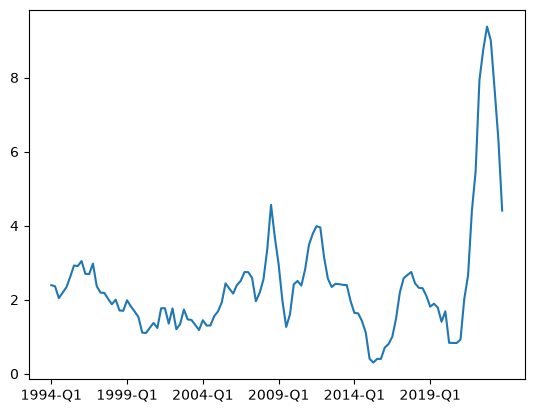

In [10]:
plt.plot(cpi_yoy.loc[cpi_yoy['Reference area'] == 'United Kingdom', 'TIME_PERIOD'], \
         cpi_yoy.loc[cpi_yoy['Reference area'] == 'United Kingdom', 'OBS_VALUE'], label = 'CPI inflation')
plt.xticks(cpi_yoy.loc[cpi_yoy['Reference area'] == 'United Kingdom', 'TIME_PERIOD'][::20])
plt.show()

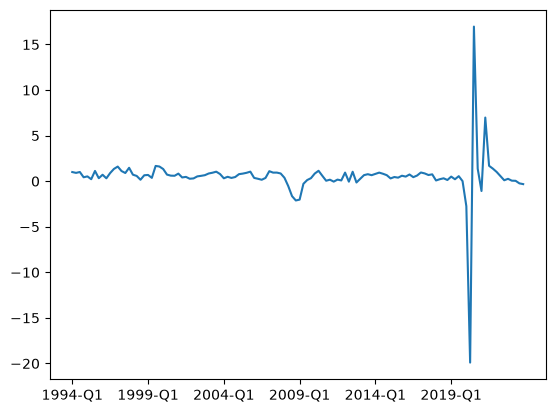

In [11]:
plt.plot(rgdp.loc[rgdp['Reference area'] == 'United Kingdom', 'TIME_PERIOD'], \
         rgdp.loc[rgdp['Reference area'] == 'United Kingdom', 'OBS_VALUE'], label = 'RGDP')
plt.xticks(rgdp.loc[rgdp['Reference area'] == 'United Kingdom', 'TIME_PERIOD'][::20])
plt.show()

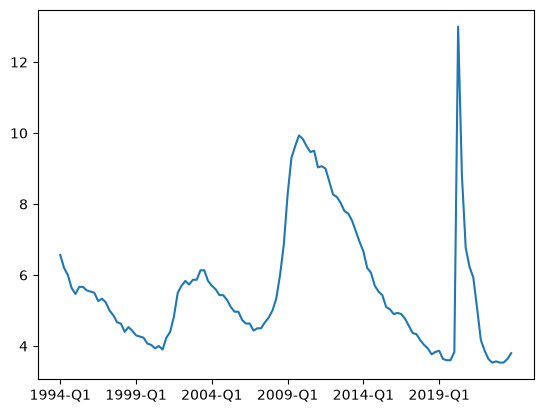

In [12]:
plt.plot(unemp.loc[unemp['Reference area'] == 'United States', 'TIME_PERIOD'], \
         unemp.loc[unemp['Reference area'] == 'United States', 'OBS_VALUE'], label = 'Unemp rate')
plt.xticks(unemp.loc[unemp['Reference area'] == 'United States', 'TIME_PERIOD'][::20])
plt.show()

In [13]:
cpi_yoy.to_csv('..\\data\\recession_test_data\\structured_data_recession\\CPI_growth_yoy_dataframe.csv')
rgdp.to_csv('..\\data\\recession_test_data\\structured_data_recession\\RGDP_growth_dataframe.csv')
unemp.to_csv('..\\data\\recession_test_data\\structured_data_recession\\unemployment_rate_dataframe.csv')